In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [127]:
df=pd.read_csv('/content/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [129]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [130]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [131]:
# percentage=df['Cabin'].isnull().sum()/len(df['Cabin'])*100
# print(f"percentage of missing values in the Cabin column: {percentage:.2f}%")
# #the percentage of missing values is 77.10% which is veary high ,so its not very impactful. Dropping this will be ok
# df=df.drop('Cabin',axis=1)

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age']=df['Age'].fillna(df['Age'].median())


df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Survived    0    1
Sex               
female     81  233
male      468  109


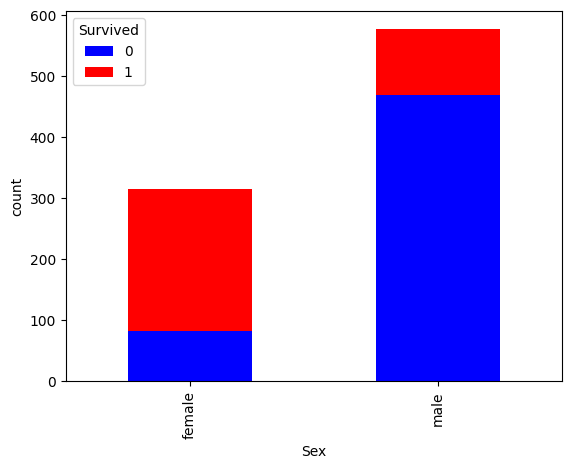

In [132]:
sur_nonsur=pd.crosstab(df['Sex'],df['Survived'])
print(sur_nonsur)
sur_nonsur.plot(kind='bar',stacked=True,color=['blue','red'])
plt.ylabel("count")
plt.show()
# female had a significantly higher survival rate :(

Pclass
1    136
2     87
3    119
Name: 1, dtype: int64


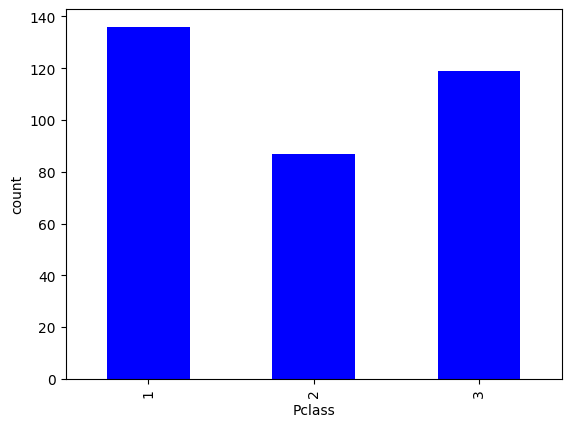

In [133]:
sur_nonsur=pd.crosstab(df['Pclass'],df['Survived'])[1]
print(sur_nonsur)
sur_nonsur.plot(kind='bar',stacked=True,color='blue')
plt.ylabel("count")
plt.show()
#yes, there a clear correlation between ticket class and survival probability,
#tier 1 people survived then tier 2 & 3

survival rate Age
False    51.183971
True     17.836257
dtype: float64


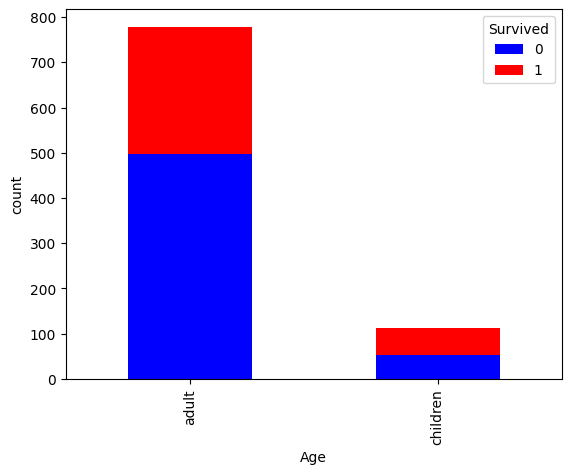

In [134]:
sur_nonsur=pd.crosstab(df['Age']<18,df['Survived'])
sur_per=sur_nonsur[1]/sur_nonsur.sum()*100
print("survival rate",sur_per)
sur_nonsur.plot(kind='bar',stacked=True,color=['blue','red'])
plt.xticks([0,1],['adult','children'])
plt.ylabel("count")
plt.show()
#survival chances of the adults is more

Embarked
C     93
Q     30
S    219
Name: 1, dtype: int64


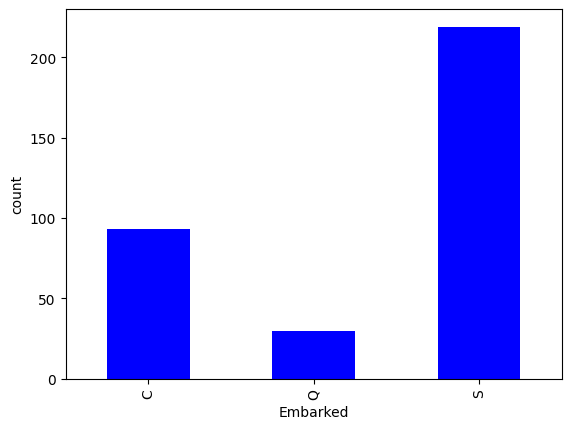

In [135]:
sur_nonsur=pd.crosstab(df['Embarked'],df['Survived'])[1]
print(sur_nonsur)
sur_nonsur.plot(kind='bar',stacked=True,color='blue')
plt.ylabel("count")
plt.show()


Based on the  data of the Titanic dataset the most significant factors affecting survival were Sex, Age, and Pclass. Females had a much higher survival rate compared to males, indicating gender was a strong predictor. Adults also had higher chances of survival than childrens. passengers in 1st class were more likely to survive than those in lower classes. Overall, Sex, Age, and Pclass appear to be the strongest predictors of survival on the Titanic.